# Task 6: Individual Root Segmentation

In this task, we perform instance segmentation at the root level. While traditional computer vision methods were sufficient for segmenting entire plants (as done in Task 3), they fall short when trying to isolate individual roots. 

Fortunately, using the deep learning-based segmentation mask from Task 5, we now aim to separate each individual root within the mask. The resulting segmented root masks for each plant will serve as the basis for extracting root system architectures in Task 7.

To achieve this, we will experiment with multiple approaches to instance segmentation, comparing their effectiveness in isolating individual roots.

This task is a preparatory step. No deliverables or client requirements are defined.


In [1]:
# Import necessary modules
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans

## Step 1: Load raw predicted mask

We begin by loading the raw predicted root mask generated in Task 5. This mask is in grayscale format with intensity values ranging from 0 to 255, where higher values indicate stronger confidence in root presence. Visualizing this raw prediction provides a baseline before we apply any post-processing or segmentation techniques.

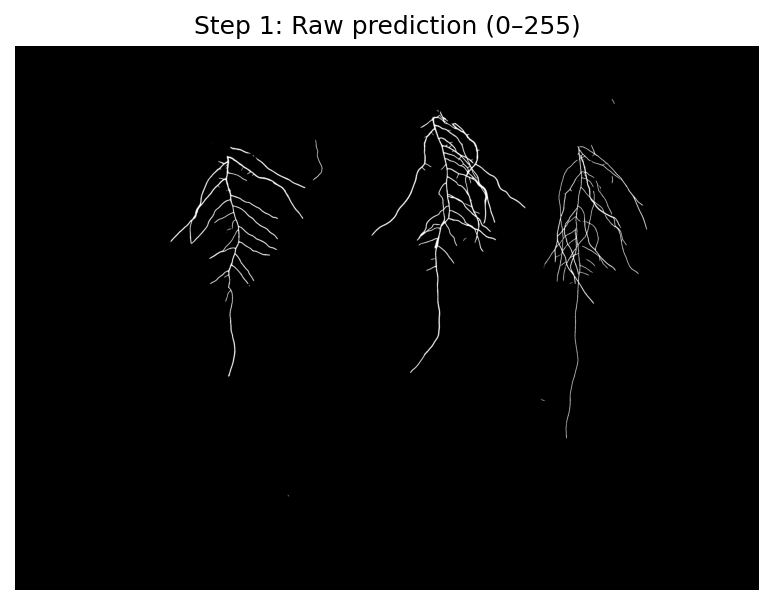

In [2]:
# Load the raw predicted mask from inference notebook task 5 (grayscale: 0–255)
raw_path = r'C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task5\10_task5_test_image_raw_prediction_viktoria_231781.png'
raw_loaded = cv2.imread(raw_path, cv2.IMREAD_GRAYSCALE)

plt.figure(dpi=150)
plt.imshow(raw_loaded, cmap='gray')
plt.title('Step 1: Raw prediction (0–255)')
plt.axis('off')
plt.show()

## Step 2: Threshold the raw prediction

To convert the raw prediction into a binary mask, we apply a threshold to the grayscale values. The threshold is defined as a fraction, and scaled to match the 0–255 intensity range. Pixels with values above this threshold are considered part of the root system and set to 1; all others are set to 0.

This step helps eliminate small, low-confidence predictions that are likely noise or artifacts, ensuring we retain only the regions where the model is more confident about root presence. The resulting binary mask provides a cleaner base for individual root segmentation in the following steps.

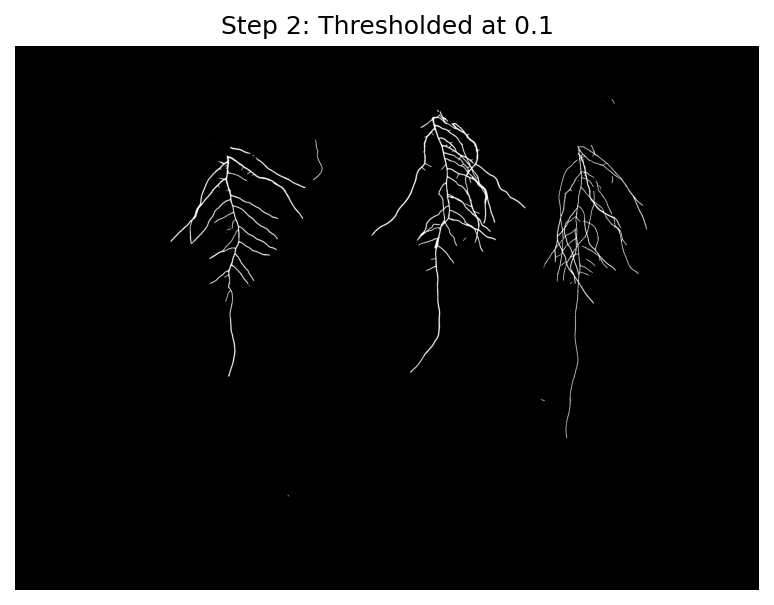

In [9]:
# Threshold the raw prediction 
threshold = 0.1
binary = (raw_loaded > int(threshold * 255)).astype(np.uint8)

plt.figure(dpi=150)
plt.imshow(binary * 255, cmap='gray')
plt.title(f'Step 2: Thresholded at {threshold}')
plt.axis('off')
plt.show()

## Step 3: Morphological closing to fill gaps

After thresholding, some roots may still appear broken or fragmented due to small gaps in the prediction. To address this, we apply morphological closing — a dilation followed by erosion — using an elliptical kernel. The elliptical shape is chosen to better match the natural curvature and orientation of roots, particularly when they appear horizontally.

We apply the closing operation multiple times to reinforce the connection of nearby segments and fill small gaps.

Initially, we experimented with manually tuning dilation and erosion separately, but this combined closing operation produced more consistent and reliable results.

The output is a smoother, more continuous binary mask, better suited for the next step: separating individual roots.

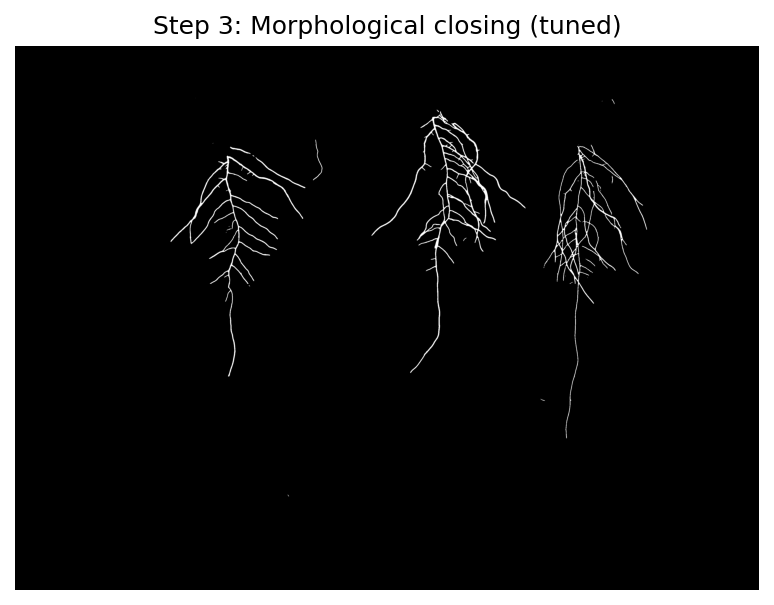

In [10]:
# Elliptical kernel to better match horizontal root gaps
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 3))  

# Apply closing multiple times
closed = binary.copy()
for _ in range(3):  # 3 passes to strengthen the closing effect
    closed = cv2.morphologyEx(closed, cv2.MORPH_CLOSE, kernel)

plt.figure(dpi=150)
plt.imshow(closed * 255, cmap='gray')
plt.title('Step 3: Morphological closing (tuned)')
plt.axis('off')
plt.show()

## Step 4: Crop empty horizontal margins

After morphological cleaning, we remove empty horizontal space from the sides of the mask. This step focuses the image on the actual root content and eliminates unnecessary black padding, which can interfere with further processing steps like contour detection or splitting the image into segment areas.

We compute the sum of pixels along each column and crop the image with a small margin around the non-zero regions. This ensures the roots remain intact while trimming unused space.


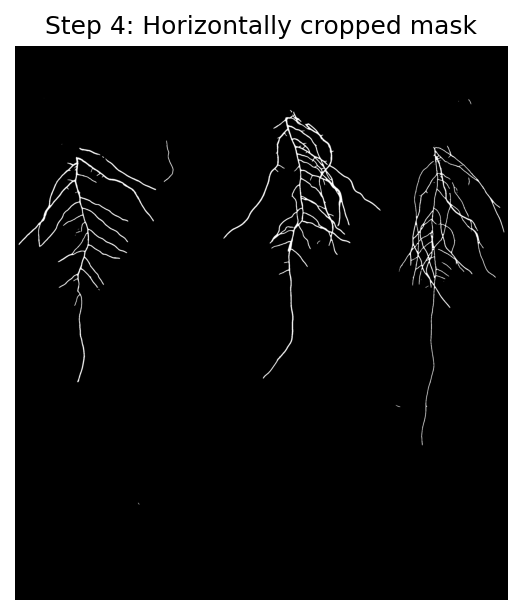

In [11]:
# Crop horizontally to remove empty sides
def crop_horizontal_mask_region(mask, margin=20):
    col_sums = np.sum(mask, axis=0)
    cols = np.where(col_sums > 0)[0]

    if len(cols) == 0:
        return mask, (0, 0)  # No content

    left_crop = max(cols[0] - margin, 0)
    right_crop = max(mask.shape[1] - cols[-1] - 1 - margin, 0)

    cropped = mask[:, left_crop:mask.shape[1] - right_crop]
    return cropped, (left_crop, right_crop)

closed_cropped, (left_crop, right_crop) = crop_horizontal_mask_region(closed)

# Visualize cropped mask
plt.figure(dpi=150)
plt.imshow(closed_cropped * 255, cmap='gray')
plt.title('Step 4: Horizontally cropped mask')
plt.axis('off')
plt.show()

## Step 5: Segment individual roots per plant

Now that we have a cleaned and cropped binary mask, we move on to segmenting individual root systems. This step aims to isolate up to five distinct root groups—one for each plant—while handling cases where roots may be fragmented, overlapping, or partially missing.

We follow a multi-stage process:
- **Connected component analysis** is used to extract root fragments.
- **Spatial proximity merging** combines nearby components likely belonging to the same plant.
- **KMeans clustering** groups the merged roots into five plant-level segments based on their centroid positions.
- **Sorting and filtering** ensures that the outputs are ordered from left to right and padded if fewer than five roots are detected.

This approach combines earlier ideas—connected components, zone-based splitting, and clustering—into a unified, robust segmentation method. The detailed comparison of all tried strategies is summarized below.

In [12]:
# Parameters
min_area = 300
num_plants = 5
max_pixel_dist = 20
min_pixels = 350

# Check if two masks are close
def components_touch(mask_a, mask_b, max_pixel_dist=15):
    kernel = np.ones((max_pixel_dist * 2 + 1, max_pixel_dist * 2 + 1), dtype=np.uint8)
    dilated = cv2.dilate(mask_a.astype(np.uint8), kernel, iterations=1)
    return np.any(np.logical_and(dilated, mask_b))

# Connected Components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed_cropped)

component_masks = []
component_centroids = []

for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        mask = (labels == i).astype(np.uint8)
        component_masks.append(mask)
        component_centroids.append(centroids[i])

# Merge close components - probably disconnected roots
merged_masks = []
used = [False] * len(component_masks)

for i in range(len(component_masks)):
    if used[i]:
        continue
    merged = component_masks[i].copy()
    used[i] = True
    for j in range(i + 1, len(component_masks)):
        if not used[j] and components_touch(merged, component_masks[j], max_pixel_dist):
            merged = np.logical_or(merged, component_masks[j])
            used[j] = True
    merged_masks.append(merged.astype(np.uint8))

# Compute centroids
centroids = []
for m in merged_masks:
    ys, xs = np.where(m)
    if len(xs) > 0:
        cx = int(np.mean(xs))
        cy = int(np.mean(ys))
        centroids.append([cx, cy])
centroids = np.array(centroids)

# Run KMeans + Sort
if len(centroids) == 0:
    print("No valid roots found. Returning 5 empty masks.")
    root_masks_sorted = [np.zeros_like(closed_cropped, dtype=np.uint8) for _ in range(num_plants)]
else:
    k = min(len(centroids), num_plants)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(centroids)

    root_masks = [np.zeros_like(closed_cropped, dtype=np.uint8) for _ in range(k)]
    for idx, mask in enumerate(merged_masks):
        root_masks[cluster_labels[idx]] = np.logical_or(root_masks[cluster_labels[idx]], mask)

    # --- Sort left to right ---
    def get_root_center_x(mask):
        ys, xs = np.where(mask)
        return np.mean(xs) if len(xs) > 0 else float('inf')

    filtered = [(i, get_root_center_x(m)) for i, m in enumerate(root_masks) if np.count_nonzero(m) >= min_pixels]
    while len(filtered) < num_plants:
        filtered.append((None, float('inf')))

    filtered_sorted = sorted(filtered, key=lambda x: x[1])

    root_masks_sorted = []
    for idx, (i, _) in enumerate(filtered_sorted):
        if i is None:
            root_masks_sorted.append(np.zeros_like(closed_cropped, dtype=np.uint8))
        else:
            root_masks_sorted.append((root_masks[i] * 255).astype(np.uint8))

# Print segmentation summary
print(f"Step 4: Segmentation complete.")
print(f"Components detected: {len(component_masks)}")
print(f"Merged root groups: {len(merged_masks)}")
print(f"Final root masks returned: {len(root_masks_sorted)} (always padded to 5)")

c:\Users\vikku\miniconda3\envs\tf_gpu\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Step 4: Segmentation complete.
Components detected: 7
Merged root groups: 6
Final root masks returned: 5 (always padded to 5)


**Concise summary of Task 6 segmentation approaches**

---

**1. Simple connected components**
- **What it did:** Used `cv2.connectedComponentsWithStats` to segment and filter by area.
- **Problem:** Did not distinguish between individual plants; returned a flat list of root objects with no per-plant separation.

---

**2. Zone-based segmentation (5 zones)**
- **What it did:** Divided the image into 5 equal vertical zones and assigned roots based on their horizontal position.
- **Problem:**
  - Disconnected roots from the same plant were split across zones.
  - Roots from neighboring plants were occasionally grouped together.
  - Overlapping or curved roots confused the zone boundaries.

---

**3. Max area per zone**
- **What it did:** Retained only the largest root component per zone.
- **Problem:** Smaller valid roots were discarded, especially for germinating seeds. Disconnected segments were not handled.

---

**4. Zone + merge close components**
- **What it did:** Attempted to merge nearby components in the same zone based on spatial proximity.
- **Problem:** Fragile results. Components from different plants were sometimes merged. Small root structures could still be missed.

---

**5. Pixel proximity merge**
- **What it did:** Used morphological dilation to merge root pieces before zone-based segmentation.
- **Problem:** Some improvement, but results were sensitive to the distance threshold. Still struggled with overlapping or crowded roots.

---

**6. KMeans clustering only**
- **What it did:** Clustered root component centroids using KMeans to form five groups.
- **Problem:** Fewer than five roots caused errors or unstable groupings. Left-to-right ordering of plants was not guaranteed.

---

**7. KMeans + pre-merge + sorted output**
- **What it does:**
  - Extracts connected components and filters them by area.
  - Merges components that are spatially close using dilation-based proximity.
  - Clusters components into up to five groups using KMeans.
  - Sorts groups by their horizontal position to enforce left-to-right order.
  - Pads the result to always return exactly five output masks.

- **Why it works:**
  - Handles disconnected root parts effectively.
  - Retains small but valid roots.
  - Avoids duplicate assignment of overlapping roots.
  - Provides consistent five-output formatting, even with missing roots.

---

**Caveat in final version**

If fewer than five plants have visible roots (e.g., one is still a seed), and the spacing between roots does not clearly indicate where the missing plant should be, the algorithm may misplace the empty zone. In this case, the generated root masks may contain all the correct root objects, but the **order may not match the actual plant positions**.

---
**Final summary**

This final approach combines morphological processing, connected component analysis, pixel-wise merging, and KMeans clustering to robustly isolate one root mask per plant. It is resilient to noise, missing data, and disconnected roots.

## Step 6: Visualize final root masks

To verify the segmentation results, we display the final set of root masks—one per plant. Each subplot shows an individual root system after all processing steps: cleaning, merging, clustering, and sorting. This visual check ensures the segmentation aligns with expected plant positions and that each mask contains a distinct root structure.

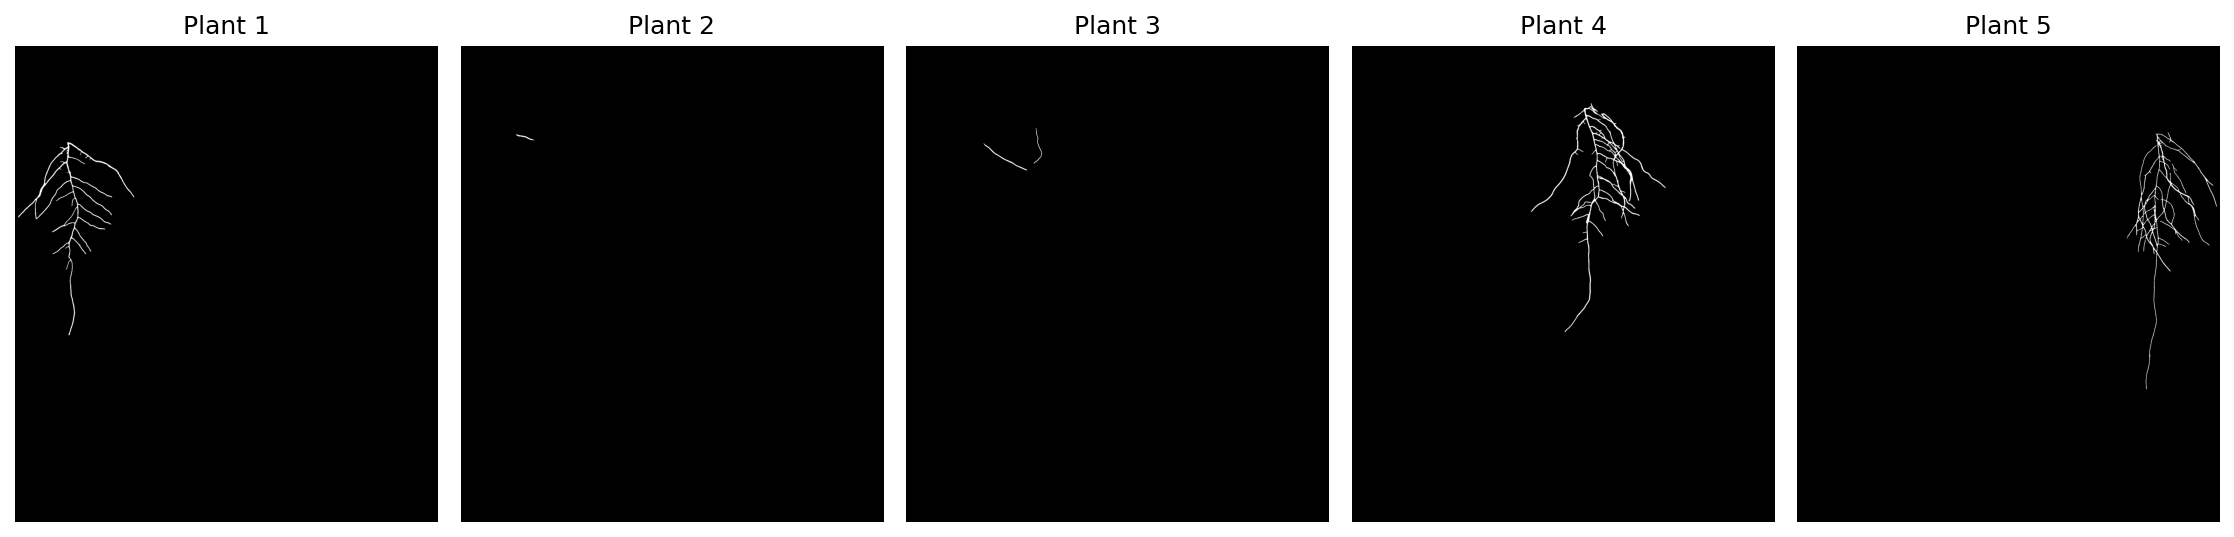

In [13]:
# Visualize Final Root Masks
plt.figure(figsize=(15, 5), dpi=150)
for idx, root in enumerate(root_masks_sorted):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(root, cmap='gray')
    plt.title(f'Plant {idx + 1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

The visualization above shows the segmented root masks for each plant. While the final approach successfully separates individual root systems into distinct masks, some challenges remain:

- The **left-to-right order of plants** or empty masks may occasionally be incorrect, especially when fewer than five root systems are present or when roots are unevenly spaced.

These limitations are acceptable for **Task 6**, as there are no formal deliverables or client requirements. The main objective—isolating roots into individual masks—was met.

However, for **Task 8**, we need to ensure that each plant's root mask is not only isolated but also **correctly ordered** from left to right. This is critical for downstream analysis and submission formatting.

---

### Step 7: Alternative strategy — centroid-based root assignment

To guarantee correct ordering, we apply a simple strategy: divide the image into **five vertical bands**, one for each plant. We detect all connected components in the top-cropped mask and assign each component to a band based on the **x-coordinate of its centroid**.

To improve reliability, we first crop a portion off the **top of the mask** to remove noise above the seed region. This focuses the analysis on actual roots and reduces the chance of mistakenly selecting floating artifacts.

This method ensures that:
- Each plant receives a mask based on spatial location.
- Output is consistently ordered from left to right.
- If no component is found for a given band, an empty mask is returned in the correct slot.

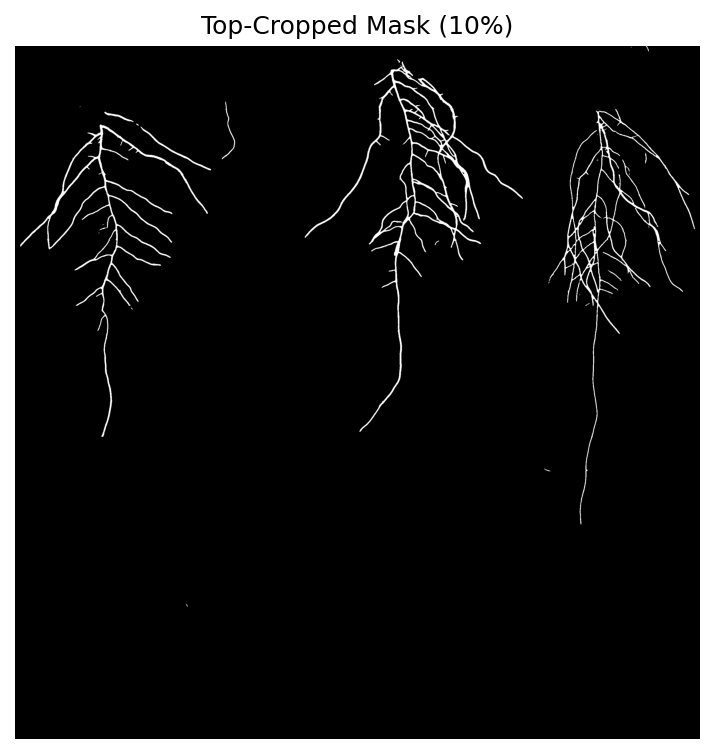

In [14]:
top_crop_ratio = 0.1  # Crop top 10% of the image

h, w = closed_cropped.shape
top_crop = int(h * top_crop_ratio)
top_cropped_mask = closed_cropped[top_crop:, :]

# Visualize the cropped mask
plt.figure(figsize=(6, 6), dpi=150)
plt.imshow(top_cropped_mask * 255, cmap='gray')
plt.title("Top-Cropped Mask (10%)")
plt.axis('off')
plt.show()

In this approach, we segment the top-cropped mask into individual plant root masks by first detecting all connected components and then assigning them to one of five vertical bands based on the x-coordinate of their **centroid**.

Each detected component is:
- Filtered by minimum area and vertical start position to exclude noise.
- Assigned to a plant based on which vertical band its centroid falls into.
- Added entirely to the corresponding output mask.


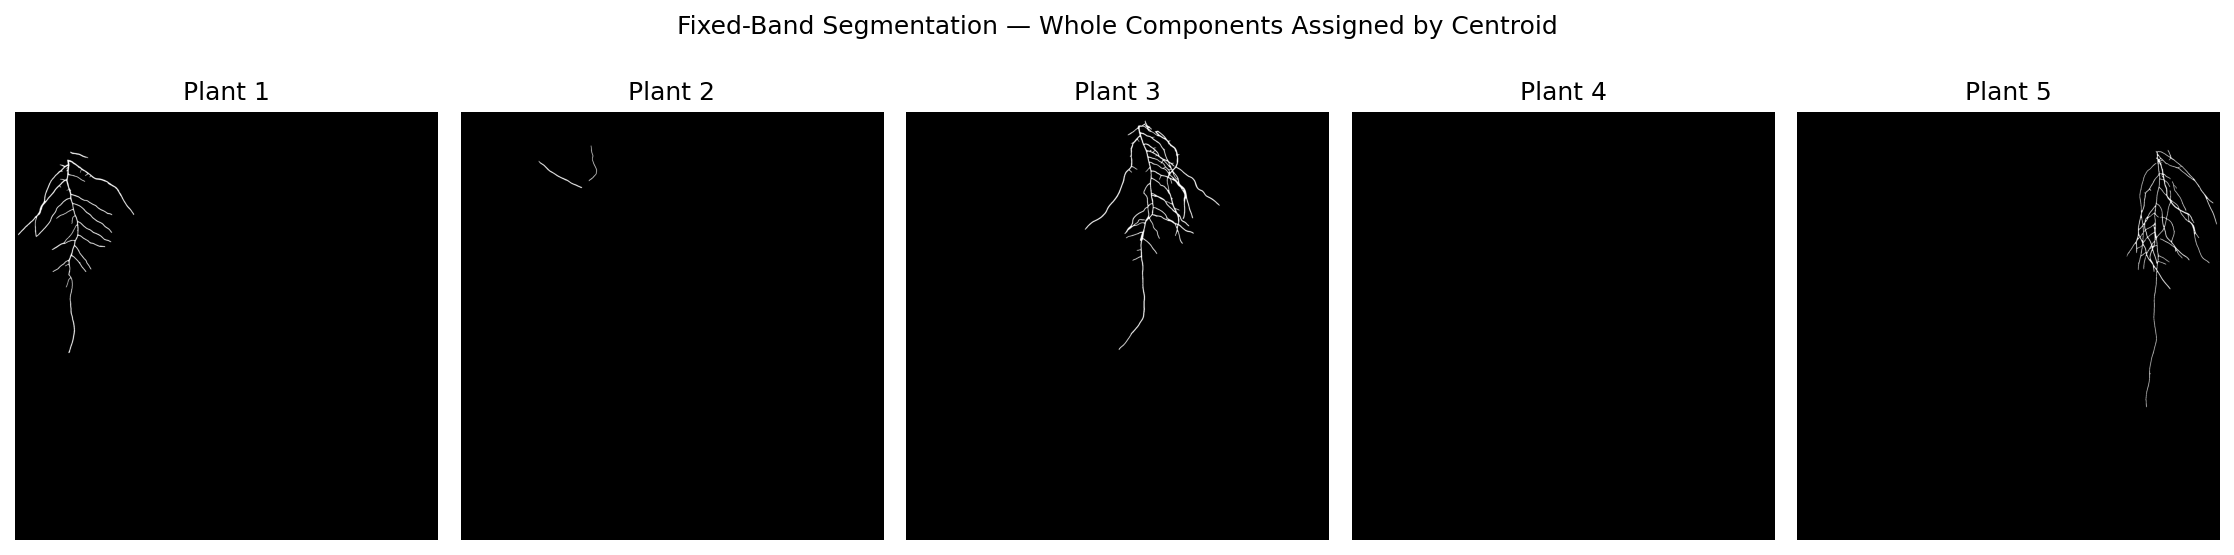

In [15]:
min_area = 250
num_plants = 5

#  Connected components on full top-cropped mask
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(top_cropped_mask)

# Initialize empty masks
final_masks = [np.zeros_like(top_cropped_mask, dtype=np.uint8) for _ in range(num_plants)]
h, w = top_cropped_mask.shape
band_width = w / num_plants  # Use float for precise binning

for i in range(1, num_labels):  # Skip background
    area = stats[i, cv2.CC_STAT_AREA]
    top_y = stats[i, cv2.CC_STAT_TOP]

    if area >= min_area and top_y < h * 0.3:
        cx = centroids[i][0]
        band_idx = int(cx // band_width)
        band_idx = min(band_idx, num_plants - 1)  # Ensure within bounds

        component_mask = (labels == i).astype(np.uint8)
        final_masks[band_idx] = np.logical_or(final_masks[band_idx], component_mask).astype(np.uint8)

# Visualize final masks
plt.figure(figsize=(15, 4), dpi=150)
for i in range(num_plants):
    plt.subplot(1, num_plants, i + 1)
    plt.imshow(final_masks[i] * 255, cmap='gray')
    plt.title(f'Plant {i + 1}')
    plt.axis('off')
plt.suptitle("Fixed-Band Segmentation — Whole Components Assigned by Centroid", fontsize=12)
plt.tight_layout()
plt.show()

The result above shows that this method generally preserves full root structures and assigns them to separate masks. However, we can see a limitation: the mask for **Plant 2** contains a lateral root that clearly belongs to **Plant 1**. This happens because the method assigns entire components based on their **centroid**, so if a root extends across bands and its centroid falls in the wrong zone, the entire root is misassigned. 

## Step 8: Final segmentation with vertical component filtering

As observed earlier, lateral roots from one plant can spill into neighboring zones, causing misassignments when using centroid-based segmentation alone. To address this, we apply an additional filtering step that selects only **vertical root components** based on their shape and position.

We detect all connected components in the top-cropped mask, then:
- Filter out small components and those starting too low in the image.
- Reject horizontally-oriented components by checking their **aspect ratio** (height must be at least 1.5× width).
- Assign each remaining component to one of five plant slots based on the **x-position of its centroid**.

This approach reliably selects the main vertical root for each plant and avoids contamination from wide lateral branches, while keeping the root masks properly ordered.

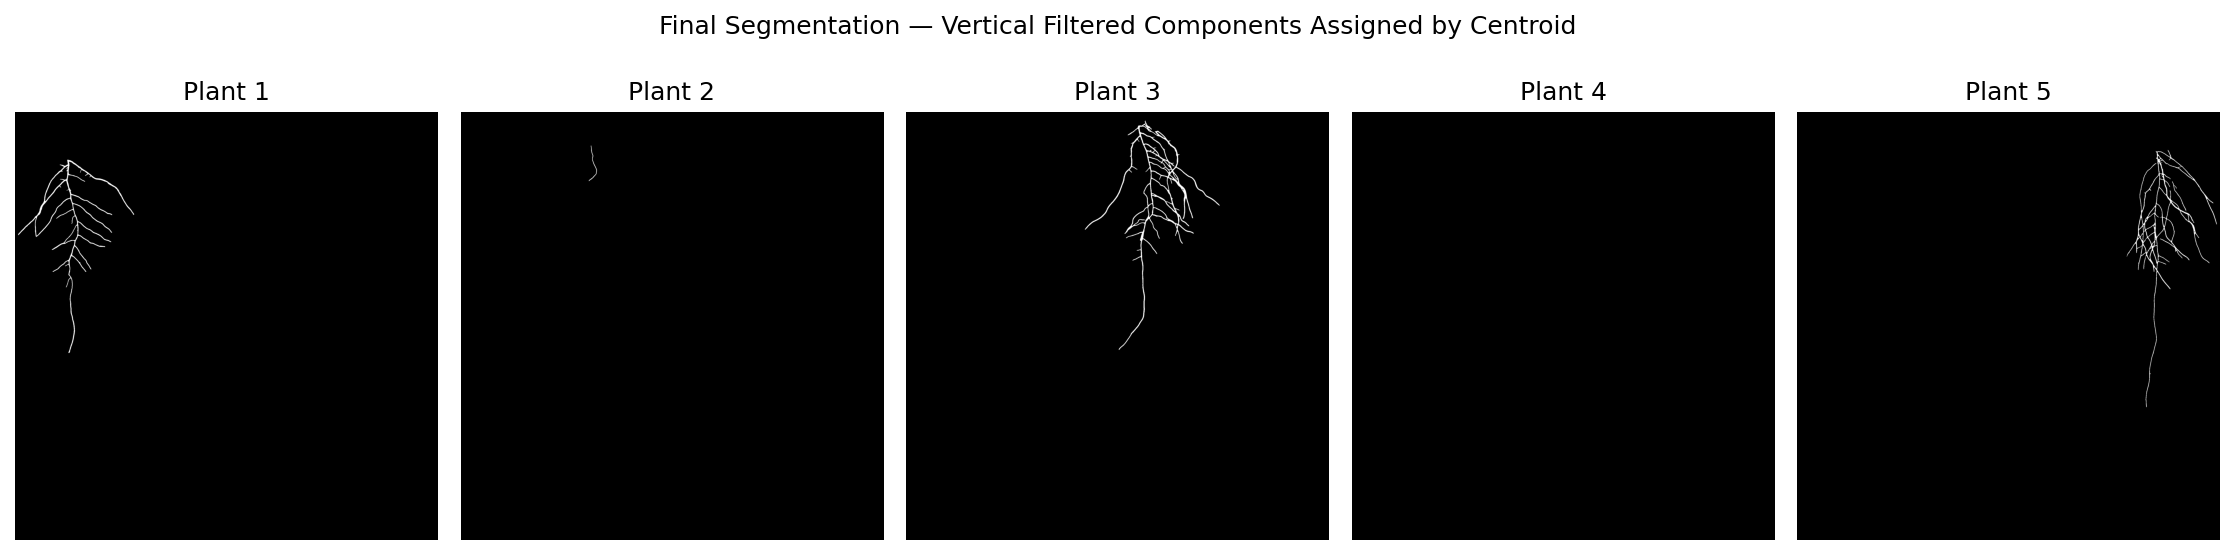

In [16]:
num_plants = 5
min_area = 250
aspect_ratio_threshold = 1.5  # height must be at least 1.5x width
vertical_start_thresh_ratio = 0.3  # filter components that start too low

# Connected components on full top-cropped mask
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(top_cropped_mask)

h, w = top_cropped_mask.shape
band_width = w / num_plants

# Initialize empty masks (1 per plant)
final_masks = [np.zeros_like(top_cropped_mask, dtype=np.uint8) for _ in range(num_plants)]

for i in range(1, num_labels):  # skip background
    x, y, cw, ch, area = stats[i]
    cx = centroids[i][0]

    if area < min_area:
        continue

    aspect_ratio = ch / cw if cw > 0 else 0
    if aspect_ratio < aspect_ratio_threshold:
        continue

    if y > int(h * vertical_start_thresh_ratio):
        continue

    band_idx = int(cx // band_width)
    band_idx = min(band_idx, num_plants - 1)

    component_mask = (labels == i).astype(np.uint8)
    final_masks[band_idx] = np.logical_or(final_masks[band_idx], component_mask).astype(np.uint8)

# Visualize result
plt.figure(figsize=(15, 4), dpi=150)
for i in range(num_plants):
    plt.subplot(1, num_plants, i + 1)
    plt.imshow(final_masks[i] * 255, cmap='gray')
    plt.title(f'Plant {i + 1}')
    plt.axis('off')
plt.suptitle("Final Segmentation — Vertical Filtered Components Assigned by Centroid", fontsize=12)
plt.tight_layout()
plt.show()


### Final result: Successful segmentation - yaaay!

The final segmentation output demonstrates that the pipeline is working as intended:

- Each plant root has been correctly assigned to its own mask.
- All masks are ordered consistently from **left to right**.
- **Lateral roots** from neighboring plants are no longer mistakenly included, thanks to the **aspect ratio filtering**.
- **Empty masks** appear only where no valid vertical root was detected, which is expected in cases of undeveloped or missing roots.

This approach is now ready to be used in the Task 8 pipeline for individual root system extraction and analysis.


In [17]:
import os

save_dir = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks"

# Ensure the save directory exists
os.makedirs(save_dir, exist_ok=True)

# Save each root mask
for i, mask in enumerate(final_masks):
    filename = os.path.join(save_dir, f"plant_{i + 1}.png")
    cv2.imwrite(filename, mask)
    print(f"Saved: {filename}")


Saved: C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_1.png
Saved: C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_2.png
Saved: C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_3.png
Saved: C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_4.png
Saved: C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task6\10_masks\plant_5.png
